# Modeling Pipeline: Preop vs Post-op Metabolic State

Notebook นี้เป็น pipeline สั้น ๆ สำหรับสร้างโมเดลจำแนก metabolic state จาก NMR metabolites ว่า sample คล้าย `preop` หรือ `post-op`

Final model ใช้ top-6 metabolites และ `ExtraTreesClassifier(criterion='entropy')` ซึ่งเป็น implementation แบบโปร่งใสของแนวคิด `ExtraTreesEntr` ที่เลือกจากผล AutoGluon/leaderboard ก่อนหน้า


## Pipeline Overview

1. Load clean EDA data
2. Create `preop/post-op` label
3. Select top-6 metabolite features
4. Split train/test แบบ group by `subject_id`
5. Scale features โดย fit scaler จาก train เท่านั้น
6. Tune ExtraTreesEntr model complexity
7. Save final predictions, confusion matrix, model file, and diagnostic plots
8. Optional: train ทีละ metabolite เพื่อดู single-feature signal และ overfit


In [1]:

# 0. Setup

from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
)
import joblib

try:
    from IPython.display import display, Image
except Exception:
    def display(obj):
        print(obj)
    Image = None

DATA_DIR = Path('.')
EDA_DIR = DATA_DIR / 'eda_outputs'
MODELING_DIR = DATA_DIR / 'modeling_outputs'
MODELING_DIR.mkdir(exist_ok=True)

CLEAN_LOG1P_PATH = EDA_DIR / 'mtbls242_log1p_sample_by_metabolite.csv'
TRAIN_TOP6_PATH = MODELING_DIR / 'train_scaled_selected_top6.csv'
TEST_TOP6_PATH = MODELING_DIR / 'test_scaled_selected_top6.csv'
SELECTED_FEATURES_PATH = MODELING_DIR / 'selected_top6_metabolite_features.json'
FEATURE_SUMMARY_PATH = MODELING_DIR / 'feature_selection_top6_summary.csv'

TUNING_DIR = MODELING_DIR / 'extratreesentr_complexity_tuning'
PLOT_DIR = MODELING_DIR / 'model_plots'
FINAL_MODEL_DIR = MODELING_DIR / 'final_model'
SINGLE_FEATURE_DIR = MODELING_DIR / 'single_feature_extratreesentr'
for folder in [TUNING_DIR, PLOT_DIR, FINAL_MODEL_DIR, SINGLE_FEATURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

LABEL_COL = 'label_preop_postop'
RANDOM_STATE = 42
OVERFIT_GAP_THRESHOLD = 0.10


## 1. Load Clean EDA Data and Create Label

ใช้ไฟล์ clean log1p จาก EDA เป็น input หลัก แล้วสร้าง label:

- `preop` = 0
- post-op ทุก time point = 1


In [2]:

# 1. Load clean data and create binary label

df = pd.read_csv(CLEAN_LOG1P_PATH)

required_metadata = ['Sample Name', 'subject_id', 'time_point', 'Factor Value[time point]']
missing_metadata = [col for col in required_metadata if col not in df.columns]
if missing_metadata:
    raise ValueError(f'Missing metadata columns: {missing_metadata}')

df[LABEL_COL] = (df['time_point'] != 'preop').astype(int)
df['label_name'] = df[LABEL_COL].map({0: 'preop', 1: 'post-op'})

overview = pd.DataFrame({
    'metric': ['samples', 'subjects', 'preop_samples', 'postop_samples'],
    'value': [
        len(df),
        df['subject_id'].nunique(),
        int((df[LABEL_COL] == 0).sum()),
        int((df[LABEL_COL] == 1).sum()),
    ],
})

display(overview)
display(df['time_point'].value_counts().rename_axis('time_point').reset_index(name='n_samples'))


,metric,value
0,samples,465
1,subjects,107
2,preop_samples,106
3,postop_samples,359


,time_point,n_samples
0,preop,106
1,3 months after surgery,98
2,6 months after surgery,98
3,9 months after surgery,92
4,12 months after surgery,71


## 2. Select Top-6 Metabolite Features

เลือก panel เล็กที่อธิบายง่ายและสัมพันธ์กับ pattern ก่อน/หลังผ่าตัดจาก EDA:

`Dimethyl sulfone`, `L-valine`, `isopropanol`, `lipoproteins`, `glycine`, `L-leucine`


In [3]:

# 2. Define top-6 feature panel

selected_features = [
    'Dimethyl sulfone',
    'L-valine',
    'isopropanol',
    'lipoproteins',
    'glycine',
    'L-leucine',
]

missing_features = [feature for feature in selected_features if feature not in df.columns]
if missing_features:
    raise ValueError(f'Selected features not found in data: {missing_features}')

feature_summary = pd.DataFrame([
    {
        'metabolite': 'Dimethyl sulfone',
        'postop_pattern': 'increase',
        'metabolic_axis': 'post-op metabolic change signal',
        'reason': 'เพิ่มหลังผ่าและช่วยชี้ post-op metabolic state',
    },
    {
        'metabolite': 'L-valine',
        'postop_pattern': 'decrease',
        'metabolic_axis': 'BCAA / protein metabolism',
        'reason': 'preop สูงและลดหลังผ่า เป็น signal สำคัญของ BCAA shift',
    },
    {
        'metabolite': 'isopropanol',
        'postop_pattern': 'decrease',
        'metabolic_axis': 'ketone/alcohol metabolism or metabolic stress',
        'reason': 'ลดลงต่อเนื่องหลังผ่าและเสริม signal นอกกลุ่ม amino acid',
    },
    {
        'metabolite': 'lipoproteins',
        'postop_pattern': 'decrease',
        'metabolic_axis': 'lipid metabolism / cardiometabolic risk',
        'reason': 'สะท้อน lipid-related metabolic profile ที่ลดหลังผ่า',
    },
    {
        'metabolite': 'glycine',
        'postop_pattern': 'increase',
        'metabolic_axis': 'amino-acid metabolism / metabolic health direction',
        'reason': 'เพิ่มหลังผ่าและเคลื่อนสวนทางกับ BCAA',
    },
    {
        'metabolite': 'L-leucine',
        'postop_pattern': 'decrease',
        'metabolic_axis': 'BCAA / protein metabolism',
        'reason': 'จับคู่กับ L-valine เพื่ออธิบาย BCAA pattern',
    },
])

SELECTED_FEATURES_PATH.write_text(json.dumps({
    'selected_top6_metabolite_features': selected_features,
    'n_selected_features': len(selected_features),
    'excluded_from_features': ['Sample Name', 'subject_id', 'time_point', 'Factor Value[time point]', LABEL_COL, 'label_name'],
}, ensure_ascii=False, indent=2))
feature_summary.to_csv(FEATURE_SUMMARY_PATH, index=False)

display(feature_summary)


,metabolite,postop_pattern,metabolic_axis,reason
0,Dimethyl sulfone,increase,post-op metabolic change signal,เพิ่มหลังผ่าและช่วยชี้ post-op metabolic state
1,L-valine,decrease,BCAA / protein metabolism,preop สูงและลดหลังผ่า เป็น signal สำคัญของ BCA...
2,isopropanol,decrease,ketone/alcohol metabolism or metabolic stress,ลดลงต่อเนื่องหลังผ่าและเสริม signal นอกกลุ่ม a...
3,lipoproteins,decrease,lipid metabolism / cardiometabolic risk,สะท้อน lipid-related metabolic profile ที่ลดหล...
4,glycine,increase,amino-acid metabolism / metabolic health direc...,เพิ่มหลังผ่าและเคลื่อนสวนทางกับ BCAA
5,L-leucine,decrease,BCAA / protein metabolism,จับคู่กับ L-valine เพื่ออธิบาย BCAA pattern


## 3. Group Train/Test Split and Train-only Scaling

แบ่ง train/test แบบ group by `subject_id` เพื่อไม่ให้ sample ของคนไข้คนเดียวกันไปอยู่ทั้งสองฝั่ง แล้ว fit scaler จาก train เท่านั้นก่อน transform test


In [4]:

# 3. Split by subject_id and scale using train statistics only

tracking_cols = ['Sample Name', 'subject_id', 'time_point', 'Factor Value[time point]']
label_cols = [LABEL_COL, 'label_name']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, df[LABEL_COL], groups=df['subject_id']))
train_raw = df.iloc[train_idx].copy().reset_index(drop=True)
test_raw = df.iloc[test_idx].copy().reset_index(drop=True)

subject_overlap = set(train_raw['subject_id']).intersection(set(test_raw['subject_id']))
if subject_overlap:
    raise ValueError(f'Subject leakage detected: {sorted(subject_overlap)[:10]}')

scaler = StandardScaler()
train_scaled_features = scaler.fit_transform(train_raw[selected_features])
test_scaled_features = scaler.transform(test_raw[selected_features])

train_scaled = train_raw[tracking_cols + label_cols].copy()
test_scaled = test_raw[tracking_cols + label_cols].copy()
train_scaled[selected_features] = train_scaled_features
test_scaled[selected_features] = test_scaled_features

# Put feature columns before labels for readability.
train_scaled = train_scaled[tracking_cols + selected_features + label_cols]
test_scaled = test_scaled[tracking_cols + selected_features + label_cols]

train_scaled.to_csv(TRAIN_TOP6_PATH, index=False)
test_scaled.to_csv(TEST_TOP6_PATH, index=False)

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'n_samples': len(train_scaled),
        'n_subjects': train_scaled['subject_id'].nunique(),
        'preop': int((train_scaled[LABEL_COL] == 0).sum()),
        'postop': int((train_scaled[LABEL_COL] == 1).sum()),
    },
    {
        'split': 'test',
        'n_samples': len(test_scaled),
        'n_subjects': test_scaled['subject_id'].nunique(),
        'preop': int((test_scaled[LABEL_COL] == 0).sum()),
        'postop': int((test_scaled[LABEL_COL] == 1).sum()),
    },
])

scale_check = pd.DataFrame({
    'split': ['train', 'test'],
    'max_abs_feature_mean': [
        train_scaled[selected_features].mean().abs().max(),
        test_scaled[selected_features].mean().abs().max(),
    ],
    'min_feature_std': [
        train_scaled[selected_features].std(ddof=0).min(),
        test_scaled[selected_features].std(ddof=0).min(),
    ],
    'max_feature_std': [
        train_scaled[selected_features].std(ddof=0).max(),
        test_scaled[selected_features].std(ddof=0).max(),
    ],
})

display(split_summary)
display(scale_check)
print(f'Saved train file: {TRAIN_TOP6_PATH}')
print(f'Saved test file: {TEST_TOP6_PATH}')


,split,n_samples,n_subjects,preop,postop
0,train,373,85,84,289
1,test,92,22,22,70


,split,max_abs_feature_mean,min_feature_std,max_feature_std
0,train,3.857504e-15,1.000000,1.000000
1,test,2.933716e-01,0.961433,1.203247


Saved train file: modeling_outputs/train_scaled_selected_top6.csv
Saved test file: modeling_outputs/test_scaled_selected_top6.csv


## 4. Tune ExtraTreesEntr Model Complexity

ลองหลายค่าของ `n_estimators`, `max_depth`, และ `min_samples_leaf` แล้วเลือกจาก test ROC-AUC พร้อมดู train-test gap เพื่อกัน overfit


In [5]:

# 4A. Prepare X/y and tuning grid

X_train = train_scaled[selected_features]
y_train = train_scaled[LABEL_COL]
X_test = test_scaled[selected_features]
y_test = test_scaled[LABEL_COL]

param_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': leaf}
    for n in [50, 100, 300, 500, 1000]
    for d in [2, 3, 4, 5, None]
    for leaf in [1, 3, 5, 10]
]

print(f'Tuning runs: {len(param_grid)}')
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')


Tuning runs: 100
Train shape: (373, 6), Test shape: (92, 6)


In [6]:

# 4B. Run tuning

rows = []
trained_models = []

for i, params in enumerate(param_grid, start=1):
    model = ExtraTreesClassifier(
        n_estimators=params['n_estimators'],
        criterion='entropy',
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    auc_gap = train_auc - test_auc

    row = {
        'run_order': i,
        'n_estimators': params['n_estimators'],
        'max_depth': 'None' if params['max_depth'] is None else params['max_depth'],
        'min_samples_leaf': params['min_samples_leaf'],
        'train_roc_auc': float(train_auc),
        'test_roc_auc': float(test_auc),
        'auc_gap_train_minus_test': float(auc_gap),
        'train_accuracy': float(accuracy_score(y_train, train_pred)),
        'test_accuracy': float(accuracy_score(y_test, test_pred)),
        'train_balanced_accuracy': float(balanced_accuracy_score(y_train, train_pred)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, test_pred)),
        'train_f1': float(f1_score(y_train, train_pred, zero_division=0)),
        'test_f1': float(f1_score(y_test, test_pred, zero_division=0)),
        'test_precision': float(precision_score(y_test, test_pred, zero_division=0)),
        'test_recall': float(recall_score(y_test, test_pred, zero_division=0)),
        'overfit_flag_auc_gap_gt_0_10': bool(auc_gap > OVERFIT_GAP_THRESHOLD),
    }
    rows.append(row)
    trained_models.append((row, model))

tuning_results = pd.DataFrame(rows).sort_values(
    ['test_roc_auc', 'test_balanced_accuracy', 'auc_gap_train_minus_test'],
    ascending=[False, False, True],
).reset_index(drop=True)
tuning_results.insert(0, 'rank_by_test_auc', np.arange(1, len(tuning_results) + 1))

TUNING_RESULTS_PATH = TUNING_DIR / 'tuning_results.csv'
tuning_results.to_csv(TUNING_RESULTS_PATH, index=False)

display(tuning_results.head(10)[[
    'rank_by_test_auc', 'n_estimators', 'max_depth', 'min_samples_leaf',
    'train_roc_auc', 'test_roc_auc', 'auc_gap_train_minus_test',
    'test_accuracy', 'test_balanced_accuracy', 'test_f1', 'overfit_flag_auc_gap_gt_0_10',
]])
print(f'Saved tuning results: {TUNING_RESULTS_PATH}')


,rank_by_test_auc,n_estimators,max_depth,min_samples_leaf,train_roc_auc,test_roc_auc,auc_gap_train_minus_test,test_accuracy,test_balanced_accuracy,test_f1,overfit_flag_auc_gap_gt_0_10
0,1,50,None,1,1.000000,0.953571,0.046429,0.902174,0.857792,0.936170,False
1,2,300,None,10,0.976396,0.950000,0.026396,0.858696,0.875974,0.900763,False
2,3,300,5,1,0.985665,0.949351,0.036314,0.847826,0.853247,0.893939,False
3,4,100,None,1,1.000000,0.949351,0.050649,0.891304,0.850649,0.928571,False
4,5,500,5,5,0.979074,0.948701,0.030373,0.847826,0.853247,0.893939,False
5,6,500,5,3,0.981092,0.948701,0.032391,0.847826,0.853247,0.893939,False
6,7,100,None,10,0.975573,0.948052,0.027521,0.858696,0.875974,0.900763,False
7,8,500,5,1,0.986200,0.948052,0.038148,0.847826,0.853247,0.893939,False
8,9,50,4,10,0.970506,0.948052,0.022454,0.836957,0.846104,0.885496,False
9,10,1000,5,3,0.981710,0.948052,0.033658,0.836957,0.846104,0.885496,False


Saved tuning results: modeling_outputs/extratreesentr_complexity_tuning/tuning_results.csv


## 5. Save Final Tuned Model and Test Outputs

เลือกโมเดลที่ test ROC-AUC ดีและ train-test gap ไม่เกิน 0.10 ถ้ามีหลายตัวใกล้กัน ให้เลือกตัวที่ gap ต่ำกว่าและอธิบายง่ายกว่า


In [8]:

# 5. Select final model, save predictions and model artifact

eligible = tuning_results[tuning_results['auc_gap_train_minus_test'] <= OVERFIT_GAP_THRESHOLD].copy()
if len(eligible) == 0:
    eligible = tuning_results.copy()

best_row = eligible.sort_values(
    ['test_roc_auc', 'test_balanced_accuracy', 'auc_gap_train_minus_test'],
    ascending=[False, False, True],
).iloc[0]

def row_matches(a, b):
    return (
        int(a['n_estimators']) == int(b['n_estimators'])
        and str(a['max_depth']) == str(b['max_depth'])
        and int(a['min_samples_leaf']) == int(b['min_samples_leaf'])
    )

final_model = None
for model_row, model in trained_models:
    if row_matches(best_row, model_row):
        final_model = model
        break
if final_model is None:
    raise RuntimeError('Could not find selected final model from tuning run.')

train_proba = final_model.predict_proba(X_train)[:, 1]
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = final_model.predict(X_test)

final_metrics = {
    'train_roc_auc': float(roc_auc_score(y_train, train_proba)),
    'test_roc_auc': float(roc_auc_score(y_test, test_proba)),
    'auc_gap_train_minus_test': float(roc_auc_score(y_train, train_proba) - roc_auc_score(y_test, test_proba)),
    'test_accuracy': float(accuracy_score(y_test, test_pred)),
    'test_balanced_accuracy': float(balanced_accuracy_score(y_test, test_pred)),
    'test_f1': float(f1_score(y_test, test_pred, zero_division=0)),
    'test_precision': float(precision_score(y_test, test_pred, zero_division=0)),
    'test_recall': float(recall_score(y_test, test_pred, zero_division=0)),
}

prediction_output = test_scaled[['Sample Name', 'subject_id', 'time_point', 'label_name', LABEL_COL]].copy()
prediction_output['predicted_label'] = test_pred
prediction_output['predicted_label_name'] = prediction_output['predicted_label'].map({0: 'preop', 1: 'post-op'})
prediction_output['post_op_probability'] = test_proba
prediction_output['correct_prediction'] = prediction_output['predicted_label'] == prediction_output[LABEL_COL]

cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred, labels=[0, 1]),
    index=['actual_preop', 'actual_postop'],
    columns=['pred_preop', 'pred_postop'],
)

BEST_MODEL_PATH = FINAL_MODEL_DIR / 'extratreesentr_top6.joblib'
BEST_PREDICTIONS_PATH = TUNING_DIR / 'best_model_test_predictions.csv'
BEST_CONFUSION_PATH = TUNING_DIR / 'best_model_confusion_matrix.csv'
BEST_METADATA_PATH = TUNING_DIR / 'metadata.json'

joblib.dump(final_model, BEST_MODEL_PATH)
prediction_output.to_csv(BEST_PREDICTIONS_PATH, index=False)
cm.to_csv(BEST_CONFUSION_PATH)
BEST_METADATA_PATH.write_text(json.dumps({
    'model_name': 'ExtraTreesEntr equivalent - sklearn ExtraTreesClassifier with criterion entropy',
    'selected_params': {
        'n_estimators': int(best_row['n_estimators']),
        'max_depth': None if str(best_row['max_depth']) == 'None' else int(best_row['max_depth']),
        'min_samples_leaf': int(best_row['min_samples_leaf']),
    },
    'features': selected_features,
    'label_column': LABEL_COL,
    'metrics': final_metrics,
    'output_files': {
        'model': str(BEST_MODEL_PATH),
        'predictions': str(BEST_PREDICTIONS_PATH),
        'confusion_matrix': str(BEST_CONFUSION_PATH),
        'tuning_results': str(TUNING_RESULTS_PATH),
    },
}, ensure_ascii=False, indent=2))

print('Final model params:')
print(best_row[['n_estimators', 'max_depth', 'min_samples_leaf']].to_dict())
display(pd.DataFrame([final_metrics]))
display(cm)
print(f'Saved model: {BEST_MODEL_PATH}')
print(f'Saved predictions: {BEST_PREDICTIONS_PATH}')


Final model params:
{'n_estimators': 50, 'max_depth': 'None', 'min_samples_leaf': 1}


,train_roc_auc,test_roc_auc,auc_gap_train_minus_test,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall
0,1.0,0.953571,0.046429,0.902174,0.857792,0.93617,0.929577,0.942857


,pred_preop,pred_postop
actual_preop,17,5
actual_postop,4,66


Saved model: modeling_outputs/final_model/extratreesentr_top6.joblib
Saved predictions: modeling_outputs/extratreesentr_complexity_tuning/best_model_test_predictions.csv


## 6. Plot Model Diagnostics

กราฟนี้ใช้ตอบว่า model output ตรงไหม และมี overfit ไหม โดยดู train/test AUC, ROC curve, confusion matrix และ probability distribution


Saved diagnostic plot: modeling_outputs/model_plots/extratreesentr_train_test_diagnostics.png
Saved tuning gap plot: modeling_outputs/model_plots/extratreesentr_tuning_auc_gap.png


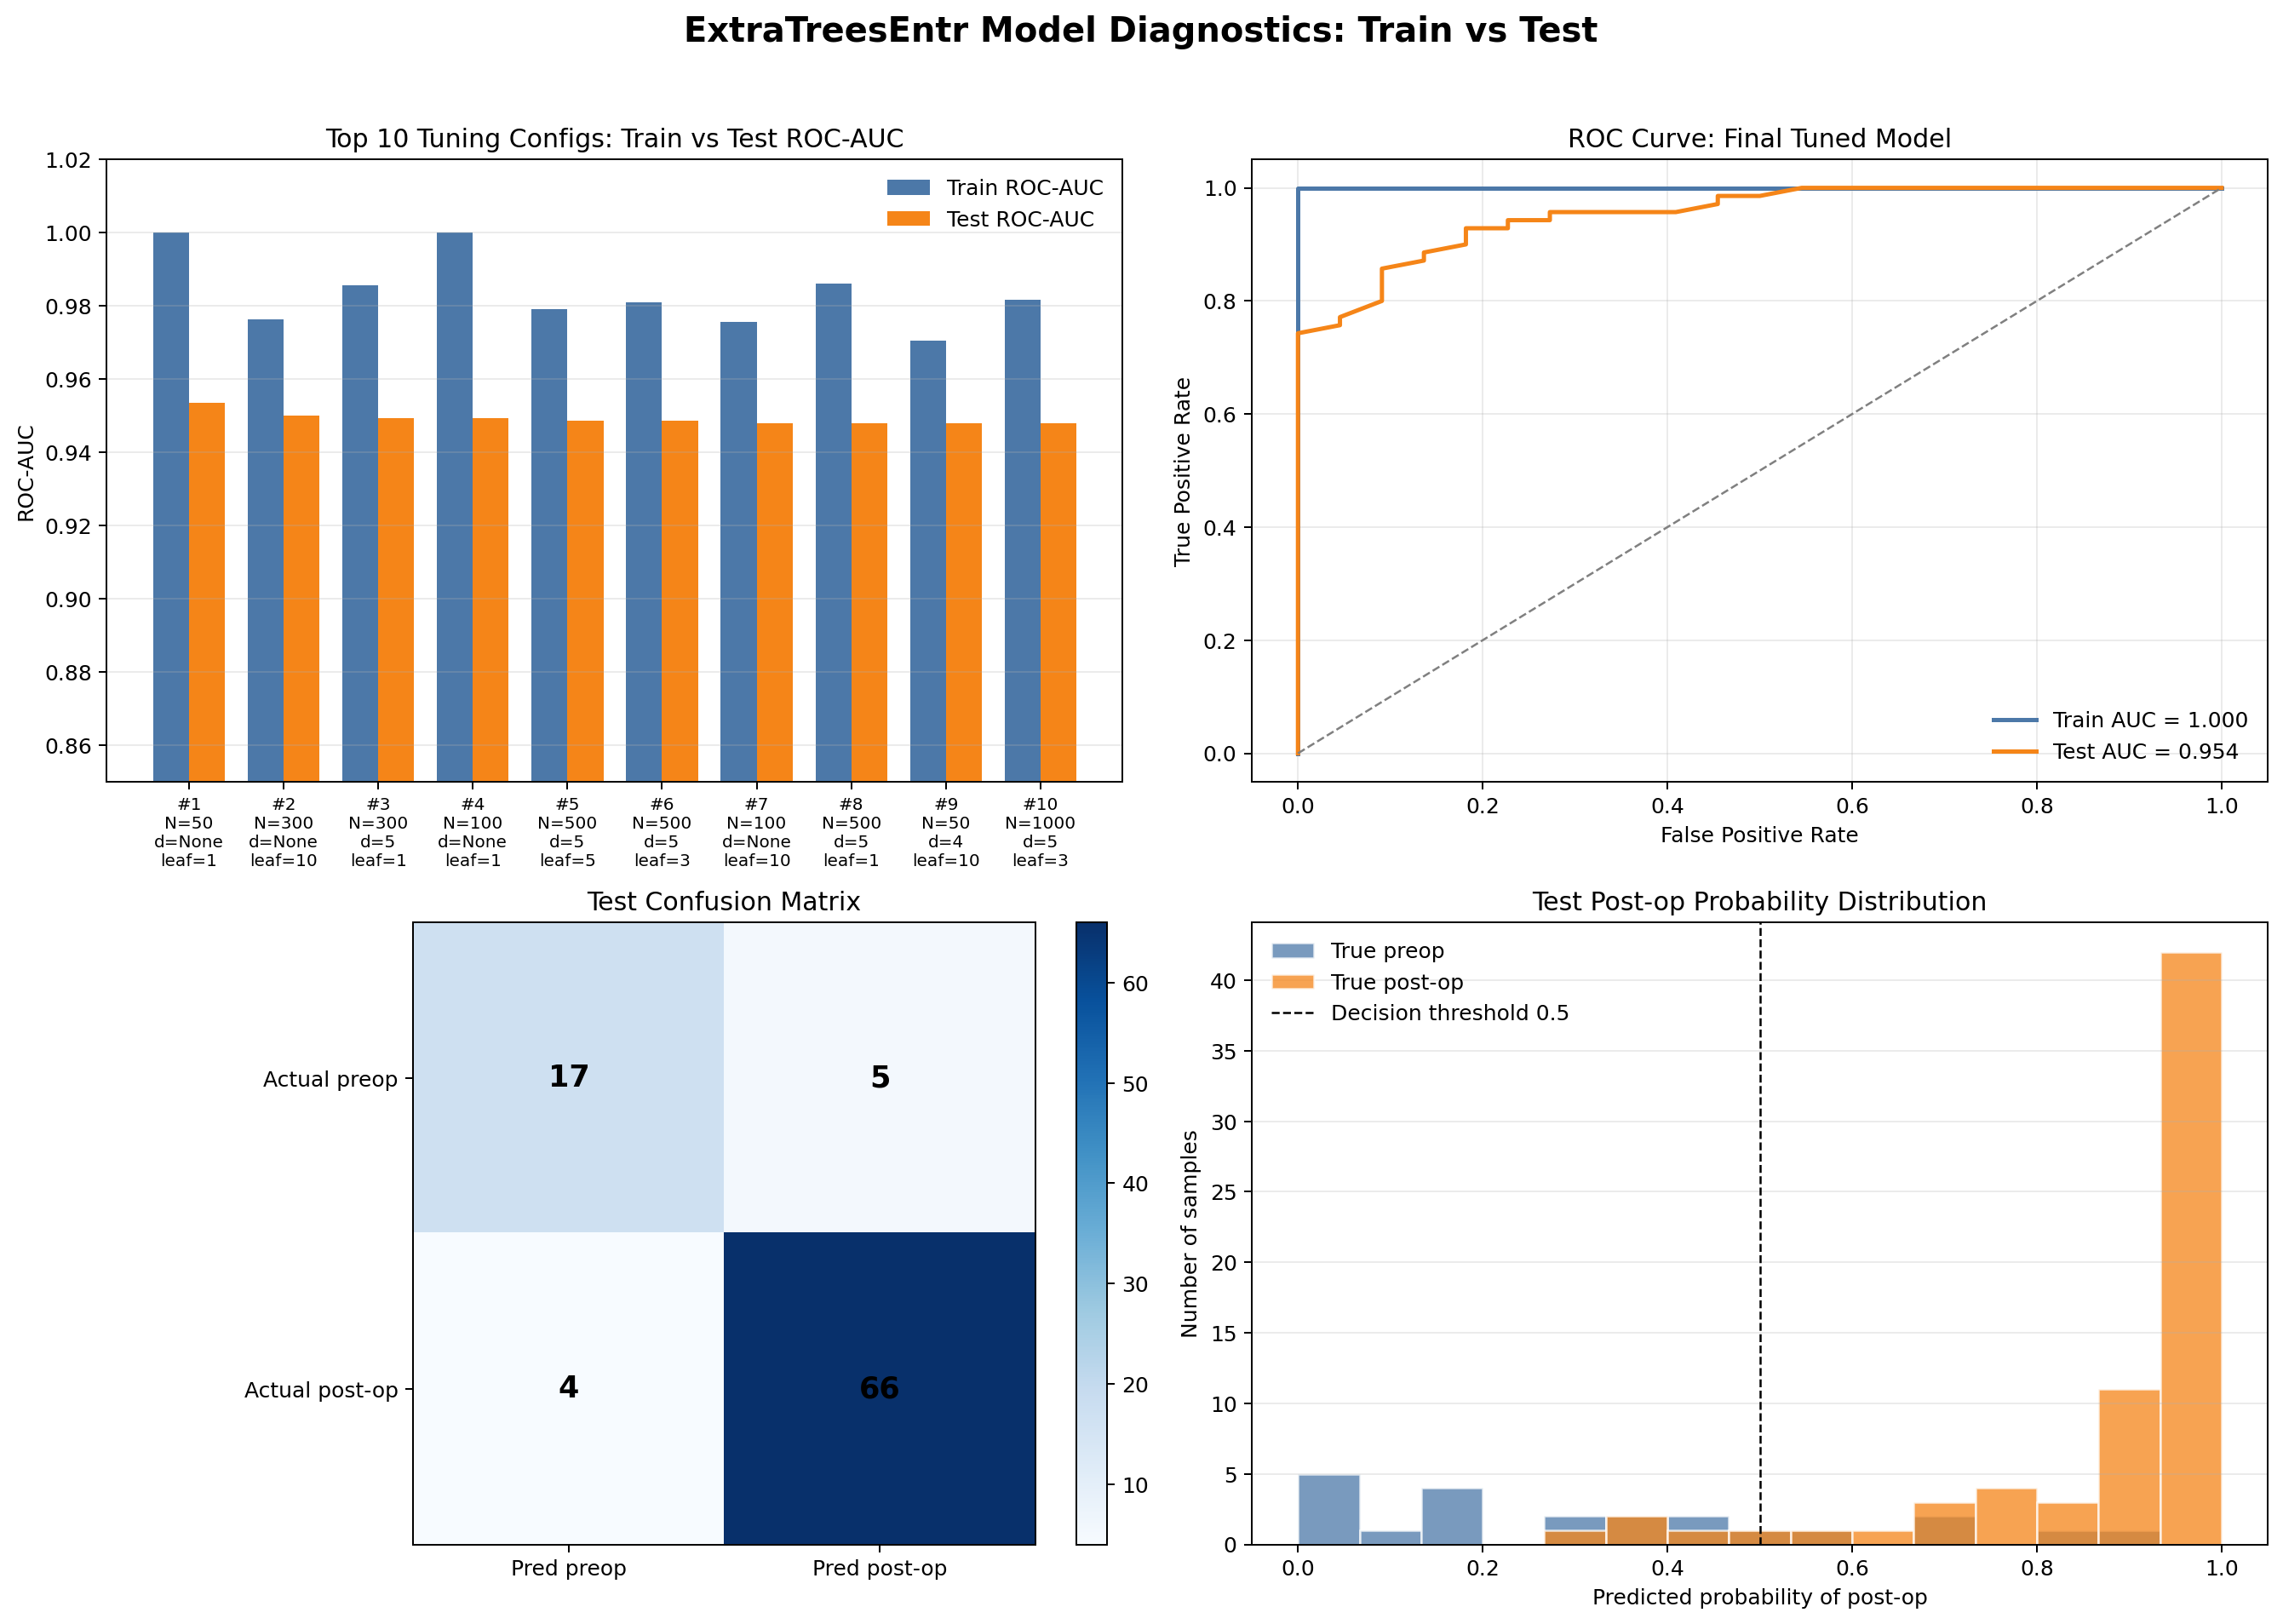

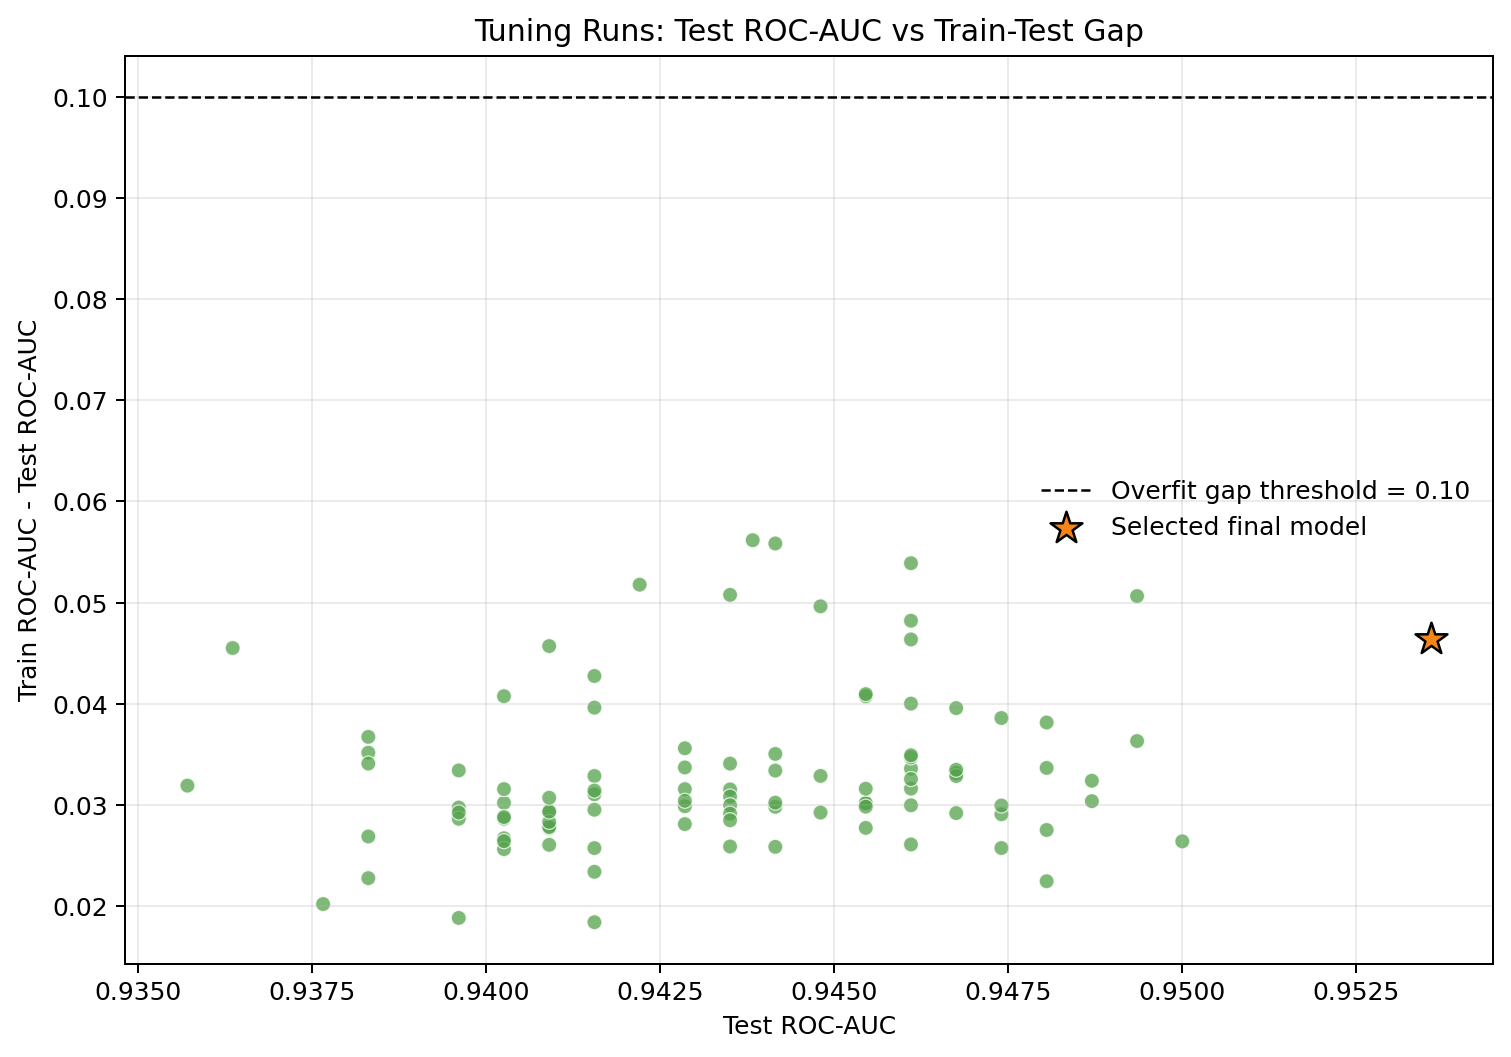

In [9]:

# 6. Plot train/test diagnostics

os.environ.setdefault('MPLCONFIGDIR', str((DATA_DIR / '.matplotlib_cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

DIAGNOSTIC_PLOT_PATH = PLOT_DIR / 'extratreesentr_train_test_diagnostics.png'
TUNING_GAP_PLOT_PATH = PLOT_DIR / 'extratreesentr_tuning_auc_gap.png'
PLOT_SUMMARY_PATH = PLOT_DIR / 'plot_summary.json'

fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)
train_auc = final_metrics['train_roc_auc']
test_auc = final_metrics['test_roc_auc']

top10 = tuning_results.head(10).copy()
top10['config_label'] = [
    f"#{i+1}\nN={int(row.n_estimators)}\nd={row.max_depth}\nleaf={int(row.min_samples_leaf)}"
    for i, row in enumerate(top10.itertuples())
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('ExtraTreesEntr Model Diagnostics: Train vs Test', fontsize=16, fontweight='bold')

ax = axes[0, 0]
x = np.arange(len(top10))
bar_w = 0.38
ax.bar(x - bar_w / 2, top10['train_roc_auc'], width=bar_w, label='Train ROC-AUC', color='#4C78A8')
ax.bar(x + bar_w / 2, top10['test_roc_auc'], width=bar_w, label='Test ROC-AUC', color='#F58518')
ax.set_ylim(0.85, 1.02)
ax.set_title('Top 10 Tuning Configs: Train vs Test ROC-AUC')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(top10['config_label'], fontsize=8)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

ax = axes[0, 1]
ax.plot(fpr_train, tpr_train, label=f'Train AUC = {train_auc:.3f}', color='#4C78A8', linewidth=2)
ax.plot(fpr_test, tpr_test, label=f'Test AUC = {test_auc:.3f}', color='#F58518', linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_title('ROC Curve: Final Tuned Model')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.25)

ax = axes[1, 0]
im = ax.imshow(cm.values, cmap='Blues')
ax.set_title('Test Confusion Matrix')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred preop', 'Pred post-op'])
ax.set_yticklabels(['Actual preop', 'Actual post-op'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.values[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 1]
bins = np.linspace(0, 1, 16)
ax.hist(test_proba[y_test.values == 0], bins=bins, alpha=0.75, label='True preop', color='#4C78A8', edgecolor='white')
ax.hist(test_proba[y_test.values == 1], bins=bins, alpha=0.75, label='True post-op', color='#F58518', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold 0.5')
ax.set_title('Test Post-op Probability Distribution')
ax.set_xlabel('Predicted probability of post-op')
ax.set_ylabel('Number of samples')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(DIAGNOSTIC_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.close(fig)

fig2, ax = plt.subplots(figsize=(8.5, 6))
colors = np.where(tuning_results['overfit_flag_auc_gap_gt_0_10'], '#E45756', '#54A24B')
ax.scatter(tuning_results['test_roc_auc'], tuning_results['auc_gap_train_minus_test'], c=colors, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axhline(OVERFIT_GAP_THRESHOLD, color='black', linestyle='--', linewidth=1, label='Overfit gap threshold = 0.10')
ax.scatter([test_auc], [train_auc - test_auc], s=180, color='#F58518', edgecolor='black', marker='*', label='Selected final model')
ax.set_title('Tuning Runs: Test ROC-AUC vs Train-Test Gap')
ax.set_xlabel('Test ROC-AUC')
ax.set_ylabel('Train ROC-AUC - Test ROC-AUC')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
fig2.savefig(TUNING_GAP_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.close(fig2)

PLOT_SUMMARY_PATH.write_text(json.dumps({
    'diagnostic_plot': str(DIAGNOSTIC_PLOT_PATH),
    'tuning_gap_plot': str(TUNING_GAP_PLOT_PATH),
    'train_roc_auc': train_auc,
    'test_roc_auc': test_auc,
    'auc_gap_train_minus_test': train_auc - test_auc,
    'confusion_matrix': cm.values.tolist(),
}, ensure_ascii=False, indent=2))

print(f'Saved diagnostic plot: {DIAGNOSTIC_PLOT_PATH}')
print(f'Saved tuning gap plot: {TUNING_GAP_PLOT_PATH}')
if Image is not None:
    display(Image(filename=str(DIAGNOSTIC_PLOT_PATH)))
    display(Image(filename=str(TUNING_GAP_PLOT_PATH)))


## 7. Optional: Single-Feature Check

Cell นี้ไม่ใช่ final model แต่ใช้ดูว่า metabolite เดี่ยวตัวไหนมี signal ดี และตัวไหน overfit ง่าย


In [10]:

# 7. Optional single-feature signal check

single_rows = []
for feature in selected_features:
    model = ExtraTreesClassifier(
        n_estimators=500,
        criterion='entropy',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train[[feature]], y_train)

    one_train_proba = model.predict_proba(X_train[[feature]])[:, 1]
    one_test_proba = model.predict_proba(X_test[[feature]])[:, 1]
    one_test_pred = model.predict(X_test[[feature]])

    train_auc_one = roc_auc_score(y_train, one_train_proba)
    test_auc_one = roc_auc_score(y_test, one_test_proba)

    single_rows.append({
        'metabolite': feature,
        'train_roc_auc': float(train_auc_one),
        'test_roc_auc': float(test_auc_one),
        'auc_gap_train_minus_test': float(train_auc_one - test_auc_one),
        'test_accuracy': float(accuracy_score(y_test, one_test_pred)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, one_test_pred)),
        'test_f1': float(f1_score(y_test, one_test_pred, zero_division=0)),
        'overfit_flag_auc_gap_gt_0_10': bool((train_auc_one - test_auc_one) > OVERFIT_GAP_THRESHOLD),
    })

single_feature_metrics = pd.DataFrame(single_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
single_feature_metrics.insert(0, 'rank_by_test_auc', np.arange(1, len(single_feature_metrics) + 1))

SINGLE_FEATURE_METRICS_PATH = SINGLE_FEATURE_DIR / 'one_feature_metrics.csv'
single_feature_metrics.to_csv(SINGLE_FEATURE_METRICS_PATH, index=False)

display(single_feature_metrics)
print(f'Saved single-feature metrics: {SINGLE_FEATURE_METRICS_PATH}')


,rank_by_test_auc,metabolite,train_roc_auc,test_roc_auc,auc_gap_train_minus_test,test_accuracy,test_balanced_accuracy,test_f1,overfit_flag_auc_gap_gt_0_10
0,1,L-valine,1.0,0.801948,0.198052,0.826087,0.714286,0.890411,True
1,2,Dimethyl sulfone,1.0,0.775649,0.224351,0.804348,0.715584,0.873239,True
2,3,L-leucine,1.0,0.736364,0.263636,0.771739,0.662987,0.853147,True
3,4,isopropanol,1.0,0.735390,0.264610,0.717391,0.611688,0.814286,True
4,5,lipoproteins,1.0,0.705519,0.294481,0.684783,0.605844,0.785185,True
5,6,glycine,1.0,0.592532,0.407468,0.717391,0.564935,0.821918,True


Saved single-feature metrics: modeling_outputs/single_feature_extratreesentr/one_feature_metrics.csv


## Final Outputs to Use

ไฟล์หลักที่ใช้ส่งงาน/ทำ presentation:

- `modeling_outputs/train_scaled_selected_top6.csv`
- `modeling_outputs/test_scaled_selected_top6.csv`
- `modeling_outputs/selected_top6_metabolite_features.json`
- `modeling_outputs/extratreesentr_complexity_tuning/tuning_results.csv`
- `modeling_outputs/extratreesentr_complexity_tuning/best_model_test_predictions.csv`
- `modeling_outputs/extratreesentr_complexity_tuning/best_model_confusion_matrix.csv`
- `modeling_outputs/final_model/extratreesentr_top6.joblib`
- `modeling_outputs/model_plots/extratreesentr_train_test_diagnostics.png`
- `modeling_outputs/model_plots/extratreesentr_tuning_auc_gap.png`
